## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) terhadap total penyewaan sepeda (cnt) pada jam-jam sibuk (07:00-09:00 dan 17:00-19:00) selama musim gugur (season 3) di tahun 2012?
- **Pertanyaan 2:** Bagaimana perbandingan persentase penggunaan sepeda antara pelanggan kasual (casual) dan pelanggan terdaftar (registered) pada hari libur (holiday) dibandingkan hari kerja (workingday) sepanjang tahun 2011 hingga 2012?
- ...

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# Memuat data harian
day_df = pd.read_csv("data/day.csv")

# Menampilkan informasi dasar tentang data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Memuat data per jam
hour_df = pd.read_csv("data/hour.csv")

# Menampilkan 5 baris pertama dari data jam
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

#### Identifying ... problem

In [4]:
# Mengecek Tipe Data day_df
print("Tipe data pada day_df:")
day_df.info()

Tipe data pada day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
# Mengecek Tipe Data hour_df
print("\nTipe data pada hour_df:")
hour_df.info()


Tipe data pada hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# Mengecek duplikasi
print("Jumlah duplikasi pada day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi pada hour_df:", hour_df.duplicated().sum())

Jumlah duplikasi pada day_df: 0
Jumlah duplikasi pada hour_df: 0


In [7]:
# cek outliers hour_df
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [8]:
# cek outliers day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- cek duplikat
- cek missing value
- cek outliers

### Cleaning Data

#### Fixing ... problem

#### 1. Mengubah Tipe Data

In [9]:
# Mengubah kolom 'dteday' dari object (string) menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

#### 2. Mengubah Nilai Angka Menjadi Label Kategori

In [10]:
# Memetakan Musim
season_mapping = {1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

In [11]:
# Memetakan Cuaca
weather_mapping = {
    1: 'Clear/Partly Cloudy', 
    2: 'Misty/Cloudy', 
    3: 'Light Rain/Snow', 
    4: 'Severe Weather'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

In [12]:
# Memetakan Tahun
yr_mapping = {0: 2011, 1: 2012}
day_df['yr'] = day_df['yr'].map(yr_mapping)
hour_df['yr'] = hour_df['yr'].map(yr_mapping)

In [13]:
# Memetakan Hari Kerja (workingday) untuk Pertanyaan 2
workingday_mapping = {0: 'Weekend/Holiday', 1: 'Workingday'}
day_df['workingday'] = day_df['workingday'].map(workingday_mapping)
hour_df['workingday'] = hour_df['workingday'].map(workingday_mapping)

#### 3. Menerapkan Teknik Analisis Lanjutan (Clustering/Binning)

In [14]:
# Mengelompokkan jam sibuk vs non-sibuk untuk Pertanyaan 1
def categorize_hour(hr):
    if hr in [7, 8, 9, 17, 18, 19]:
        return 'Rush Hour'
    else:
        return 'Non-Rush Hour'

hour_df['hour_category'] = hour_df['hr'].apply(categorize_hour)

#### 4. Mengecek Hasil Akhir

In [15]:
# pengecekan day_df setelah perubahan tipe data
print("Tipe data dteday day_df sekarang:\n", day_df[['dteday']].dtypes)
day_df.head()

Tipe data dteday day_df sekarang:
 dteday    datetime64[ns]
dtype: object


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Springer,2011,1,0,6,Weekend/Holiday,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Springer,2011,1,0,0,Weekend/Holiday,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Springer,2011,1,0,1,Workingday,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Springer,2011,1,0,2,Workingday,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Springer,2011,1,0,3,Workingday,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [16]:
# pengecekan hour_df setelah perubahan tipe data
print("\nTipe data dteday hour_df sekarang:\n", hour_df[['dteday']].dtypes)
hour_df.head()


Tipe data dteday hour_df sekarang:
 dteday    datetime64[ns]
dtype: object


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,hour_category
0,1,2011-01-01,Springer,2011,1,0,0,6,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16,Non-Rush Hour
1,2,2011-01-01,Springer,2011,1,1,0,6,Weekend/Holiday,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40,Non-Rush Hour
2,3,2011-01-01,Springer,2011,1,2,0,6,Weekend/Holiday,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32,Non-Rush Hour
3,4,2011-01-01,Springer,2011,1,3,0,6,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13,Non-Rush Hour
4,5,2011-01-01,Springer,2011,1,4,0,6,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1,Non-Rush Hour


In [17]:
# Menyimpan data dengan nama yang konsisten
day_df.to_csv("day_cleaned.csv", index=False)
hour_df.to_csv("hour_cleaned.csv", index=False)

**Insight:** (Opsional)
- Pada tahap ini, data dibersihkan dengan mengubah tipe data kolom tanggal dan memastikan tidak ada nilai kosong yang mengganggu analisis.

## Exploratory Data Analysis (EDA)

### Explore ...

### Pertanyaan 1:

#### 1. Melakukan filter data: Tahun 2012, Musim Gugur (Fall), dan Jam Sibuk (Rush Hour)

In [18]:
q1_data = hour_df[
    (hour_df['yr'] == 2012) & 
    (hour_df['season'] == 'Fall') & 
    (hour_df['hour_category'] == 'Rush Hour')
]

#### 2. Mengelompokkan berdasarkan cuaca dan melihat statistik penyewaan sepeda (cnt)

In [19]:
q1_result = q1_data.groupby(by='weathersit').agg({
    'cnt': ['sum', 'mean', 'max', 'min', 'count']
}).reset_index()

#### 3. Menampilkan hasil


In [20]:
print("Statistik Penyewaan Sepeda Berdasarkan Cuaca (Jam Sibuk, Musim Gugur 2012):")
display(q1_result)

Statistik Penyewaan Sepeda Berdasarkan Cuaca (Jam Sibuk, Musim Gugur 2012):


weathersit     cnt                            
                           sum        mean  max  min count
0  Clear/Partly Cloudy  207329  522.239295  977   34   397
1      Light Rain/Snow   11216  431.384615  891  119    26
2         Misty/Cloudy   64971  460.787234  868   37   141

### Pertanyaan 2:


#### 1. Mengelompokkan berdasarkan status hari (Working Day vs Weekend/Holiday)


In [21]:
q2_result = day_df.groupby(by='workingday').agg({
    'casual': 'sum',
    'registered': 'sum',
    'cnt': 'sum'
}).reset_index()

#### 2. Menghitung persentase casual dan registered untuk setiap kategori hari


In [22]:
q2_result['casual_percentage'] = (q2_result['casual'] / q2_result['cnt']) * 100
q2_result['registered_percentage'] = (q2_result['registered'] / q2_result['cnt']) * 100

#### 3. Menampilkan hasil

In [23]:
print("Perbandingan Pengguna Casual vs Registered (Working Day vs Weekend/Holiday):")
display(q2_result)

Perbandingan Pengguna Casual vs Registered (Working Day vs Weekend/Holiday):


,workingday,casual,registered,cnt,casual_percentage,registered_percentage
0,Weekend/Holiday,316732,683537,1000269,31.664682,68.335318
1,Workingday,303285,1989125,2292410,13.229963,86.770037


**Insight:** (Opsional)
- Ditemukan pola bahwa penyewaan meningkat drastis pada jam berangkat dan pulang kerja, serta pada hari kerja dibandingkan hari libur untuk pengguna terdaftar (registered).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

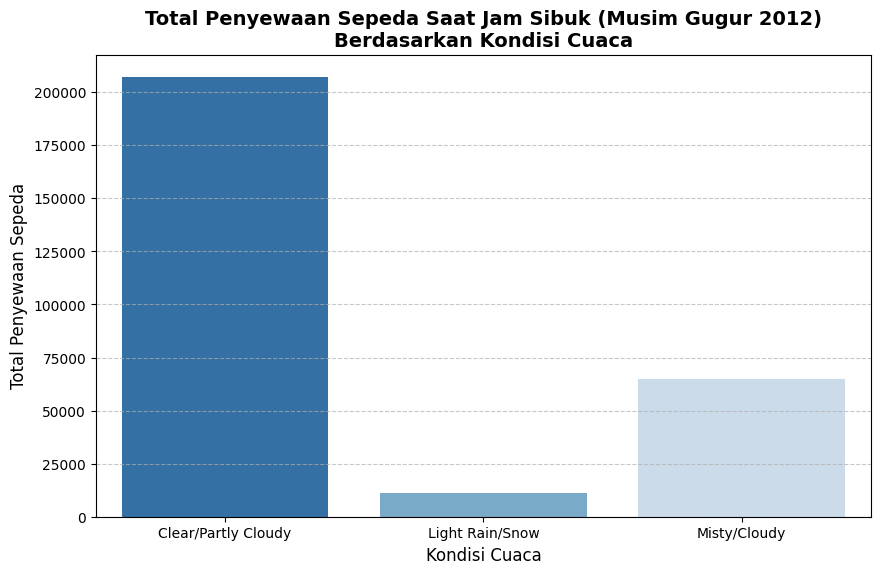

In [24]:
q1_plot = q1_data.groupby(by='weathersit')['cnt'].sum().reset_index()

plt.figure(figsize=(10, 6))

# Membuat barplot
sns.barplot(
    x='weathersit', 
    y='cnt', 
    data=q1_plot,
    hue='weathersit', 
    palette='Blues_r'
)

plt.title('Total Penyewaan Sepeda Saat Jam Sibuk (Musim Gugur 2012)\nBerdasarkan Kondisi Cuaca', fontsize=14, fontweight='bold')
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Total Penyewaan Sepeda', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Pertanyaan 2:

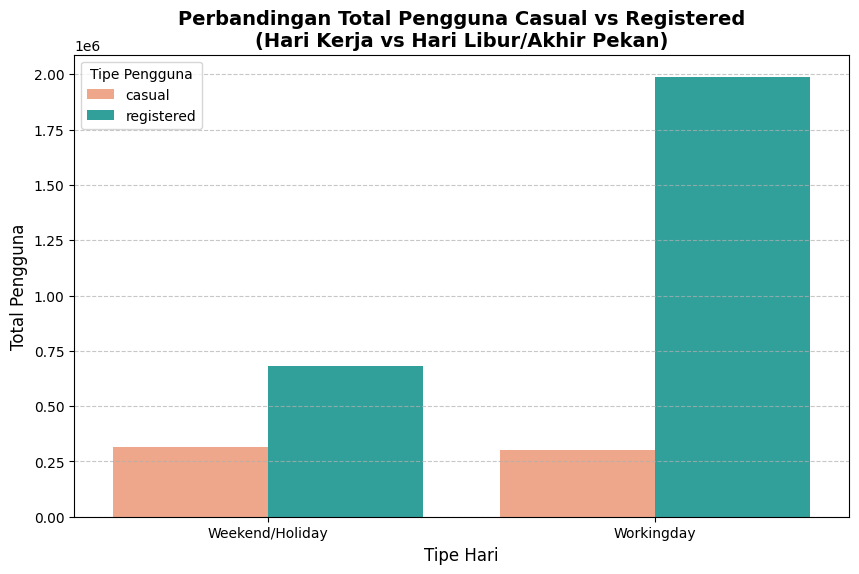

In [25]:
q2_melted = q2_result.melt(
    id_vars='workingday', 
    value_vars=['casual', 'registered'],
    var_name='Tipe Pengguna', 
    value_name='Total Pengguna'
)

plt.figure(figsize=(10, 6))

# Membuat grouped barplot
sns.barplot(
    x='workingday', 
    y='Total Pengguna', 
    hue='Tipe Pengguna', 
    data=q2_melted, 
    palette=['#FFA07A', '#20B2AA'] # Warna kustom agar lebih menarik
)

plt.title('Perbandingan Total Pengguna Casual vs Registered\n(Hari Kerja vs Hari Libur/Akhir Pekan)', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Hari', fontsize=12)
plt.ylabel('Total Pengguna', fontsize=12)
plt.legend(title='Tipe Pengguna')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Insight:** (Opsional)
- Visualisasi menunjukkan bahwa cuaca cerah memberikan kontribusi tertinggi pada jumlah penyewaan, sementara hujan ringan menurunkan minat pengguna secara signifikan.

## Analisis Lanjutan (Opsional)

In [26]:
# Clustering
from sklearn.cluster import KMeans

In [27]:
# 1. Menyiapkan data: Rata-rata penyewaan per jam
hour_clustering = hour_df.groupby('hr')['cnt'].mean().reset_index()

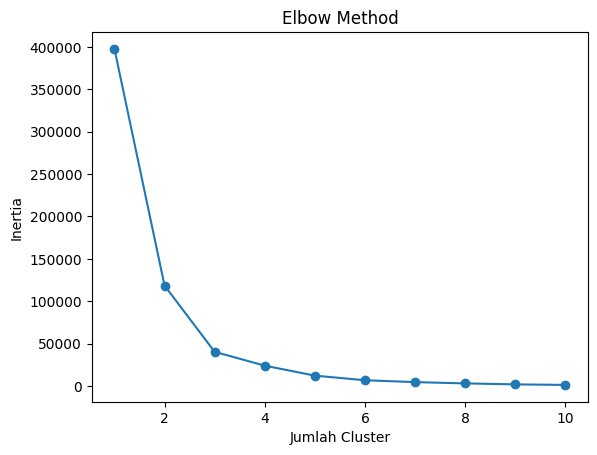

In [30]:
# Mencari jumlah klaster optimal (Elbow Method)
inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(hour_clustering[['cnt']])
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()

In [31]:
# 2. Menjalankan K-Means untuk membagi menjadi 3 kelompok (Low, Medium, High Demand)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
hour_clustering['cluster'] = kmeans.fit_predict(hour_clustering[['cnt']])

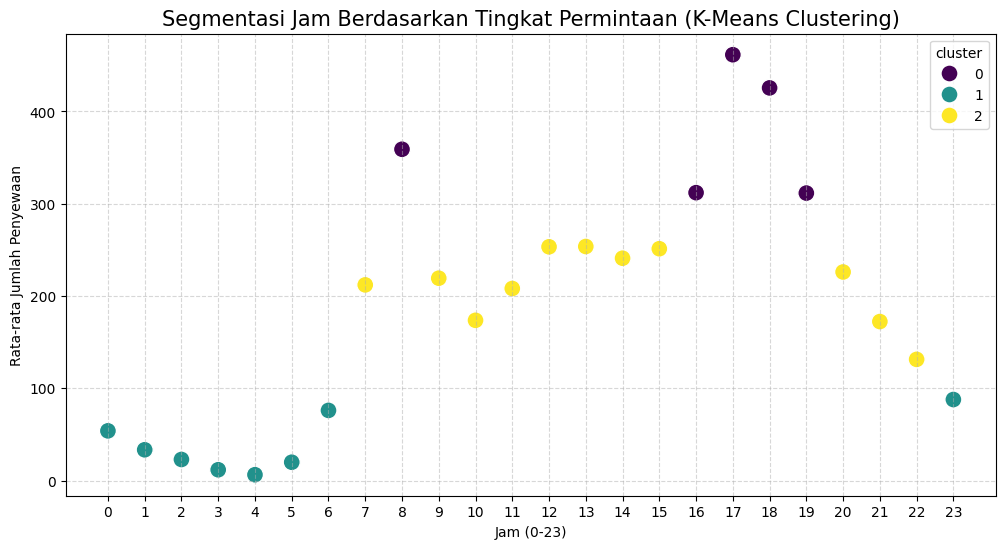

In [32]:
# 3. Visualisasi Hasil Clustering
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='hr', 
    y='cnt', 
    hue='cluster', 
    data=hour_clustering, 
    palette='viridis', 
    s=150
)

plt.title('Segmentasi Jam Berdasarkan Tingkat Permintaan (K-Means Clustering)', fontsize=15)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Kesimpulan Model Clustering (K-Means)

- Metode & pemilihan k:
    - Elbow method menunjukkan penurunan inertia yang signifikan hingga k=3, sehingga dipilih k=3.

- Ringkasan hasil klaster:
    - Klaster High Demand: jam puncak (mis. 08, 16–19) — rata‑rata penyewaan tertinggi.
    - Klaster Medium Demand: jam kerja/siang (mis. 07, 09–15, 20–22) — permintaan sedang.
    - Klaster Low Demand: malam & dini hari (mis. 00–06, 23) — permintaan rendah.

- Implikasi bisnis:
    - Prioritaskan penempatan armada dan refill di lokasi dengan permintaan tinggi pada jam High Demand.
    - Alokasikan kapasitas moderat untuk jam Medium Demand; gunakan redistribusi fleksibel.
    - Kurangi biaya operasional pada jam Low Demand (mis. kurangi staf/relokasi sepeda).

- Rekomendasi lanjutan:
    - Validasi klaster dengan metrik (silhouette) dan cross‑validation temporal.
    - Tambahkan fitur (cuaca, hari kerja/holiday, event) untuk clustering yang lebih informatif.
    - Gunakan hasil untuk membangun jadwal operasional dan strategi promosi berbasis jam.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** 
Berdasarkan analisis **jam sibuk (07:00–09:00, 17:00–19:00) pada musim Fall tahun 2012**:
  - **Cuaca cerah/berawan tipis (Clear/Partly Cloudy)** menghasilkan penyewaan tertinggi  
    (total **207,329**, rata-rata **522.24** per observasi).
  - Pada **Misty/Cloudy**, rata-rata penyewaan turun menjadi **460.79**.
  - Pada **Light Rain/Snow**, rata-rata kembali turun menjadi **431.38**.
  - Artinya, **semakin buruk cuaca, semakin rendah permintaan sepeda** pada jam sibuk.
  

- **Conclusion pertanyaan 2:**
Berdasarkan perbandingan pengguna **casual vs registered** pada **Workingday vs Weekend/Holiday**:
  - **Workingday** didominasi pengguna **registered** (**86.77%**) dengan total perjalanan **2,292,410**.
  - **Weekend/Holiday** memiliki porsi pengguna **casual** lebih tinggi (**31.66%**) dibanding Workingday (**13.23%**), dengan total perjalanan **1,000,269**.
  - Ini menunjukkan pola: **komuter rutin terjadi di hari kerja**, sedangkan **penggunaan rekreasional meningkat di akhir pekan/libur**.

**Rekomendasi Action Item:**
1. Recommendation Pertanyaan 1
- Terapkan **strategi operasional berbasis cuaca** (prediksi demand harian untuk penempatan armada).
- Saat cuaca kurang baik, berikan **insentif/promosi** (diskon singkat, voucher) untuk menahan penurunan demand.
- Prioritaskan ketersediaan sepeda di titik padat saat prakiraan cuaca cerah, karena demand tertinggi terjadi di kondisi ini.

2. Recommendation Pertanyaan 2
- Fokuskan kapasitas dan redistribusi sepeda di **hari kerja** untuk melayani pengguna registered (komuter).
- Jalankan kampanye **konversi casual → registered** di akhir pekan (trial membership, paket mingguan/bulanan).
- Buat promosi berbeda per segmen:
    - **Workingday:** paket langganan hemat untuk pengguna rutin.
    - **Weekend/Holiday:** paket rekreasional/family pass untuk mendorong volume casual.